🧹 Preprocessing text...
⚙️ Building TF-IDF...
🚀 Training stacking model (TF-IDF)...
✅ Training completed

=== FINAL TEST EVALUATION ===
Accuracy : 0.9131422083451604
Precision: 0.8256227758007118
Recall   : 0.6904761904761905
F1-score : 0.7520259319286872
AUC      : 0.9485122179352276

=== CLASSIFICATION REPORT (PER LABEL) ===
              precision    recall  f1-score   support

     Label 0     0.9298    0.9656    0.9474      2851
     Label 1     0.8256    0.6905    0.7520       672

    accuracy                         0.9131      3523
   macro avg     0.8777    0.8281    0.8497      3523
weighted avg     0.9099    0.9131    0.9101      3523

=== CONFUSION MATRIX ===
[[2753   98]
 [ 208  464]]


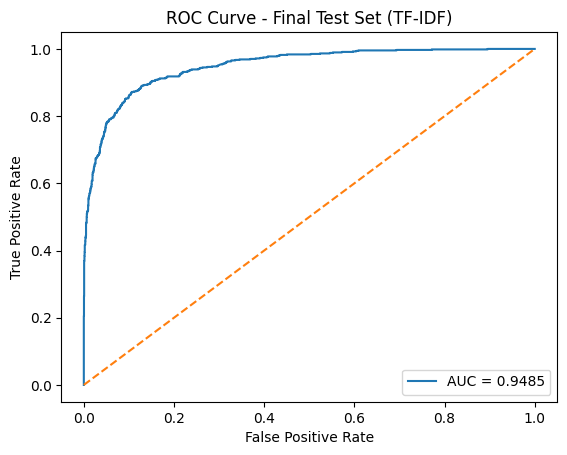

In [2]:
# =====================================================
# STACKING ENSEMBLE TF-IDF INDONESIA (SASTRAWI VERSION)
# =====================================================

import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import vstack

# 🔥 SASTRAWI
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory


# =====================================================
# SASTRAWI SETUP
# =====================================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stop_words_id = set(stop_factory.get_stop_words())

protected_stopwords = {
    'tidak','tidakkah','tidaklah','tak','bukan','bukankah','bukanlah','bukannya','tanpa','belum','belumlah',
    'jangan','janganlah','jangankan','enggak','enggaknya','aku','akulah','saya','sayalah','kami','kamilah',
    'kita','kitalah','kamu','kamulah','anda','andalah','dia','dialah','ia','ialah','mereka','merekalah',
    'apa','apaan','apakah','apatah','bagaimana','bagaimanakah','berapa','berapakah','berapalah','bilakah',
    'kapan','kapankah','kenapa','mengapa','siapa','siapakah','siapapun','mana','bisakah','bolehkah',
    'bolehlah','perlukah','mungkinkah','haruskah','benarkah','sudahkah','tapi','tetapi','namun','melainkan',
    'padahal','walau','walaupun','meski','meskipun','sebaliknya','malah','malahan'
}

final_stopwords = stop_words_id - protected_stopwords


# =====================================================
# PREPROCESSING
# =====================================================

def preprocess_text(text):
    if not isinstance(text, str):
        return []

    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = html.unescape(text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    tokens = [t for t in tokens if t not in final_stopwords]
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens


def preprocess_joined(text):
    tokens = preprocess_text(text)
    return " ".join(tokens)


# =====================================================
# STACKING MODEL (DEFAULT PARAMS)
# =====================================================

def build_stacking_model_default():
    base_learners = [
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier()),
        ('svm', SVC(probability=True))
    ]

    meta_learner = LogisticRegression(max_iter=1000)

    return StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5,
        n_jobs=-1
    )


# =====================================================
# LOAD DATA
# =====================================================

dataset_a = pd.read_csv('data_80.csv')
dataset_b = pd.read_csv('data_20.csv')

X_a = dataset_a['Text']
y_a = dataset_a['label']

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_a, y_a,
    test_size=0.125,
    random_state=42,
    stratify=y_a
)


# =====================================================
# TF-IDF VECTORIZATION
# =====================================================

print("🧹 Preprocessing text...")

X_train_clean = X_train_text.apply(preprocess_joined)
X_val_clean   = X_val_text.apply(preprocess_joined)
X_test_clean  = dataset_b['Text'].apply(preprocess_joined)

print("⚙️ Building TF-IDF...")

tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=5000
)

# Fit di train + val
X_combined = pd.concat([X_train_clean, X_val_clean])
X_train_val = tfidf.fit_transform(X_combined)

# Split lagi
X_train = X_train_val[:len(X_train_clean)]
X_val   = X_train_val[len(X_train_clean):]

# Transform test
X_test = tfidf.transform(X_test_clean)
y_test = dataset_b['label']


# =====================================================
# TRAINING
# =====================================================

final_model = build_stacking_model_default()

X_final = vstack([X_train, X_val])
y_final = np.concatenate([y_train, y_val])

# FIX sparse matrix biar gak read-only
X_final = X_final.copy()
X_final.sort_indices()

X_test = X_test.copy()
X_test.sort_indices()

print("🚀 Training stacking model (TF-IDF)...")
final_model.fit(X_final, y_final)
print("✅ Training completed")


# =====================================================
# EVALUATION
# =====================================================

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print('\n=== FINAL TEST EVALUATION ===')
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-score :', f1_score(y_test, y_pred))
print('AUC      :', roc_auc_score(y_test, y_proba))

print("\n=== CLASSIFICATION REPORT (PER LABEL) ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Label 0", "Label 1"],
        digits=4
    )
)

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))


# =====================================================
# ROC CURVE
# =====================================================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Test Set (TF-IDF)")
plt.legend(loc="lower right")
plt.show()

🧹 Preprocessing text...
⚙️ Building TF-IDF...
🚀 Training stacking model (TF-IDF)...
✅ Training completed

=== FINAL TEST EVALUATION ===
Accuracy : 0.9034913426057337
Precision: 0.816793893129771
Recall   : 0.6369047619047619
F1-score : 0.7157190635451505
AUC      : 0.9194280724390772

=== CLASSIFICATION REPORT (PER LABEL) ===
              precision    recall  f1-score   support

     Label 0     0.9186    0.9663    0.9419      2851
     Label 1     0.8168    0.6369    0.7157       672

    accuracy                         0.9035      3523
   macro avg     0.8677    0.8016    0.8288      3523
weighted avg     0.8992    0.9035    0.8987      3523

=== CONFUSION MATRIX ===
[[2755   96]
 [ 244  428]]


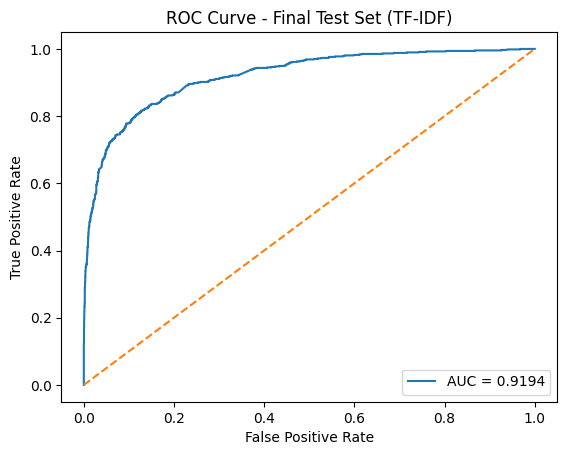

In [1]:
# =====================================================
# STACKING ENSEMBLE TF-IDF INDONESIA (SASTRAWI VERSION)
# =====================================================

import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import vstack

# 🔥 SASTRAWI
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory


# =====================================================
# SASTRAWI SETUP
# =====================================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stop_words_id = set(stop_factory.get_stop_words())

protected_stopwords = {
    'tidak','tidakkah','tidaklah','tak','bukan','bukankah','bukanlah','bukannya','tanpa','belum','belumlah',
    'jangan','janganlah','jangankan','enggak','enggaknya','aku','akulah','saya','sayalah','kami','kamilah',
    'kita','kitalah','kamu','kamulah','anda','andalah','dia','dialah','ia','ialah','mereka','merekalah',
    'apa','apaan','apakah','apatah','bagaimana','bagaimanakah','berapa','berapakah','berapalah','bilakah',
    'kapan','kapankah','kenapa','mengapa','siapa','siapakah','siapapun','mana','bisakah','bolehkah',
    'bolehlah','perlukah','mungkinkah','haruskah','benarkah','sudahkah','tapi','tetapi','namun','melainkan',
    'padahal','walau','walaupun','meski','meskipun','sebaliknya','malah','malahan'
}

final_stopwords = stop_words_id - protected_stopwords


# =====================================================
# PREPROCESSING
# =====================================================

def preprocess_text(text):
    if not isinstance(text, str):
        return []

    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = html.unescape(text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()

    tokens = [t for t in tokens if t not in final_stopwords]
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens


def preprocess_joined(text):
    tokens = preprocess_text(text)
    return " ".join(tokens)


# =====================================================
# STACKING MODEL (DEFAULT PARAMS)
# =====================================================

def build_stacking_model_default():
    base_learners = [
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier()),
        ('svm', SVC(probability=True))
    ]

    meta_learner = LogisticRegression(max_iter=1000)

    return StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=5,
        n_jobs=-1
    )


# =====================================================
# LOAD DATA
# =====================================================

dataset_a = pd.read_csv('data_80.csv')
dataset_b = pd.read_csv('data_20.csv')

X_a = dataset_a['Text']
y_a = dataset_a['label']

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_a, y_a,
    test_size=0.125,
    random_state=42,
    stratify=y_a
)


# =====================================================
# TF-IDF VECTORIZATION
# =====================================================

print("🧹 Preprocessing text...")

X_train_clean = X_train_text.apply(preprocess_joined)
X_val_clean   = X_val_text.apply(preprocess_joined)
X_test_clean  = dataset_b['Text'].apply(preprocess_joined)

print("⚙️ Building TF-IDF...")

tfidf = TfidfVectorizer(
    ngram_range=(2, 3),
    max_features=5000
)

# Fit di train + val
X_combined = pd.concat([X_train_clean, X_val_clean])
X_train_val = tfidf.fit_transform(X_combined)

# Split lagi
X_train = X_train_val[:len(X_train_clean)]
X_val   = X_train_val[len(X_train_clean):]

# Transform test
X_test = tfidf.transform(X_test_clean)
y_test = dataset_b['label']


# =====================================================
# TRAINING
# =====================================================

final_model = build_stacking_model_default()

X_final = vstack([X_train, X_val])
y_final = np.concatenate([y_train, y_val])

# FIX sparse matrix biar gak read-only
X_final = X_final.copy()
X_final.sort_indices()

X_test = X_test.copy()
X_test.sort_indices()

print("🚀 Training stacking model (TF-IDF)...")
final_model.fit(X_final, y_final)
print("✅ Training completed")


# =====================================================
# EVALUATION
# =====================================================

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print('\n=== FINAL TEST EVALUATION ===')
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-score :', f1_score(y_test, y_pred))
print('AUC      :', roc_auc_score(y_test, y_proba))

print("\n=== CLASSIFICATION REPORT (PER LABEL) ===")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Label 0", "Label 1"],
        digits=4
    )
)

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))


# =====================================================
# ROC CURVE
# =====================================================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Test Set (TF-IDF)")
plt.legend(loc="lower right")
plt.show()

In [2]:
import pandas as pd
from collections import Counter
import re
import html

# ================================
# PREPROCESS
# ================================
def preprocess_text(text):
    if not isinstance(text, str):
        return []

    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = html.unescape(text)
    text = re.sub(r'[^a-zA-Z#\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    return tokens


# ================================
# NGRAM
# ================================
def generate_ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))


# ================================
# MAIN FUNCTION (WITH LABEL COUNT)
# ================================
def create_ngram_with_label(df, n):
    all_ngrams = []
    label_0_ngrams = []
    label_1_ngrams = []

    for _, row in df.iterrows():
        tokens = row["tokens"]
        label = row["label"]

        ngrams = generate_ngrams(tokens, n)

        all_ngrams.extend(ngrams)

        if label == 0:
            label_0_ngrams.extend(ngrams)
        elif label == 1:
            label_1_ngrams.extend(ngrams)

    counter_all = Counter(all_ngrams)
    counter_0 = Counter(label_0_ngrams)
    counter_1 = Counter(label_1_ngrams)

    total = sum(counter_all.values())

    data = []
    for ngram_tuple, count in counter_all.items():
        ngram_text = " ".join(ngram_tuple)
        freq = count / total if total > 0 else 0

        count_0 = counter_0.get(ngram_tuple, 0)
        count_1 = counter_1.get(ngram_tuple, 0)

        data.append([ngram_text, count, freq, count_0, count_1])

    df_out = pd.DataFrame(
        data,
        columns=["ngram", "count", "frequency", "count_label_0", "count_label_1"]
    )

    df_out = df_out.sort_values(by="count", ascending=False)

    return df_out


# ================================
# LOAD DATA
# ================================
df = pd.read_csv("Dataset Steve.csv")

# preprocess
df["tokens"] = df["Text"].apply(preprocess_text)


# ================================
# BIGRAM
# ================================
bigram_df = create_ngram_with_label(df, 2)
bigram_df.to_csv("bigram.csv", index=False)


# ================================
# TRIGRAM
# ================================
trigram_df = create_ngram_with_label(df, 3)
trigram_df.to_csv("trigram.csv", index=False)